# Programming Assignment: Adversarial AI in Brisca

**Game chosen:** Brisca

**Students:**  Francisco Pico, Cristian Ballester

**Approach chosen:** Partially observable games  


## 1. Purpose

The purpose of this project is to build and evaluate an adversarial AI agent for Brisca, a Spanish card game where the goal is to win hands and accumulate the highest score by obtaining high value cards (Aces and Threes).

The important AI challenge is that a player does not know the opponent's hand or the future deck order. Because of that, this project treats Brisca as a partially observable adversarial game.

The goal is not just to make the program run. The goal is to show, through experiments, whether the AI performs better than simpler baseline agents.


## 2. Key Questions

This project answers the following questions:

1. Can a Brisca AI make good decisions without knowing the opponent's hidden cards?
2. Does a belief based heuristic agent perform better than a random agent?
3. Does it also perform well against a stronger heuristic baseline?
4. Is the performance consistent across different trump suits?
5. What are the strengths and limitations of this approach?

These questions guide both the implementation and the evaluation.


## 3. Rules and Scope Used

This implementation uses a simplified two player Brisca model.

**Rules included:**

- Spanish 40 card deck.
- Suits: Oros, Copas, Espadas, Bastos.
- Each player starts with 3 cards.
- One card is revealed to determine the trump suit.
- Players may play any card; they do not have to follow suit.
- A trick is won by the highest trump card, or by the highest card of the led suit if no trump is played.
- After each trick, the winner draws first, then the loser.
- The visible trump card is drawn last.
- The winner is the player with more points after all 20 tricks.

**Card values:**

| Card | Points |
|---|---:|
| Ace / 1 | 11 |
| 3 | 10 |
| King / 12 | 4 |
| Knight / 11 | 3 |
| Jack / 10 | 2 |
| 7, 6, 5, 4, 2 | 0 |

This scope keeps the project focused on adversarial decision making and partial observability rather than extra local rule variations.


## 4. Library Use

This notebook uses:

- `random`, `dataclasses`, `math`, and other standard Python tools for the game engine.
- `pandas` for summarizing experiment results.
- `matplotlib` for plotting evaluation results.

No external adversarial game library is used for Brisca because Brisca is not provided as a ready made standard environment in the common AI libraries listed in the assignment. The game specific mechanics are implemented directly, while the AI method is kept simple and explainable.

The AI does **not** re-implement Monte Carlo simulation, minimax over a full hidden state tree, or a neural network. Instead, it uses a deterministic belief state heuristic appropriate for a partially observable card game.


## 5. Imports

In [3]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict, Set, Any
from collections import defaultdict
import random
import statistics
from math import comb

import pandas as pd
import matplotlib.pyplot as plt


## 6. Card Model

The Spanish deck has 40 cards. Brisca uses a special ranking order:

**A > 3 > 12 > 11 > 10 > 7 > 6 > 5 > 4 > 2**

This ranking is different from normal numeric order because the 3 is stronger than the King, Knight, and Jack.


In [4]:
SUITS = ["Oros", "Copas", "Espadas", "Bastos"]

# Spanish deck ranks. There are no 8s or 9s.
RANKS = [1, 2, 3, 4, 5, 6, 7, 10, 11, 12]

# Point values used for scoring tricks.
POINTS = {
    1: 11,
    3: 10,
    12: 4,
    11: 3,
    10: 2,
    7: 0,
    6: 0,
    5: 0,
    4: 0,
    2: 0,
}

# Strength order used to decide which card wins a trick.
RANK_POWER = {
    1: 10,
    3: 9,
    12: 8,
    11: 7,
    10: 6,
    7: 5,
    6: 4,
    5: 3,
    4: 2,
    2: 1,
}

RANK_NAME = {
    1: "A",
    3: "3",
    12: "Rey",
    11: "Caballo",
    10: "Sota",
    7: "7",
    6: "6",
    5: "5",
    4: "4",
    2: "2",
}

SUIT_ABBR = {
    "Oros": "Or",
    "Copas": "Co",
    "Espadas": "Es",
    "Bastos": "Ba",
}


@dataclass(frozen=True, order=True)
class Card:
    suit: str
    rank: int

    def points(self) -> int:
        return POINTS[self.rank]

    def power(self) -> int:
        return RANK_POWER[self.rank]

    def short(self) -> str:
        return f"{RANK_NAME[self.rank]}-{SUIT_ABBR[self.suit]}"

    def __repr__(self) -> str:
        return self.short()


ALL_CARDS = tuple(Card(suit, rank) for suit in SUITS for rank in RANKS)

print(f"Deck size: {len(ALL_CARDS)} cards")
print("First 8 cards:", ALL_CARDS[:8])


Deck size: 40 cards
First 8 cards: (A-Or, 2-Or, 3-Or, 4-Or, 5-Or, 6-Or, 7-Or, Sota-Or)


## 7. Trick Logic

The function below decides who wins a trick.

The return value is:

- `0` if the leader wins
- `1` if the follower wins


In [5]:
def make_deck(rng: random.Random) -> List[Card]:
    """Create and shuffle a Spanish 40-card deck."""
    deck = list(ALL_CARDS)
    rng.shuffle(deck)
    return deck


def trick_winner(lead: Card, follow: Card, trump_suit: str) -> int:
    """Return 0 if the leading card wins, or 1 if the following card wins."""

    # Same suit: strongest card in that suit wins.
    if lead.suit == follow.suit:
        return 0 if lead.power() >= follow.power() else 1

    # Follower wins if they play trump and the leader did not.
    if follow.suit == trump_suit and lead.suit != trump_suit:
        return 1

    # Otherwise, the leader wins.
    return 0


def trick_points(card1: Card, card2: Card) -> int:
    """Return the total point value in a two-card trick."""
    return card1.points() + card2.points()


# Quick mechanical test
lead = Card("Oros", 1)
follow = Card("Copas", 2)
print("Leader card:", lead)
print("Follower card:", follow)
print("Trump suit: Copas")
print("Winner:", "Follower" if trick_winner(lead, follow, "Copas") == 1 else "Leader")


Leader card: A-Or
Follower card: 2-Co
Trump suit: Copas
Winner: Follower


## 8. Agent Designs

This project compares four agents.

### 8.1 Random Agent

Chooses a legal card randomly. This is the weakest baseline.

### 8.2 Greedy Agent

Uses a simple rule:

- If leading, play the highest point card.
- If following, win with the cheapest winning card if possible.
- Otherwise, discard the lowest value card.

This baseline is stronger than random but short-sighted.

### 8.3 Basic Heuristic Agent

Tries to save trump cards and high point cards. It usually leads low non-trump cards and only wins tricks when the trick has enough value.

### 8.4 Belief Heuristic AI

This is the main AI.

It uses partial observability by tracking:

- its own hand
- the trump suit
- the visible trump card
- cards already played
- number of cards left in the deck
- approximate probability that the opponent has a card that can beat the current lead

It does **not** simulate random futures. It makes a direct deterministic decision from the current belief state.


In [ ]:
class Agent:
    name = "Agent"

    def choose_card(self, obs: Dict[str, Any]) -> Card:
        raise NotImplementedError


class RandomAgent(Agent):
    name = "Random"

    def __init__(self, seed: Optional[int] = None):
        self.rng = random.Random(seed)

    def choose_card(self, obs: Dict[str, Any]) -> Card:
        return self.rng.choice(obs["hand"])


class GreedyAgent(Agent):
    name = "Greedy"

    def choose_card(self, obs: Dict[str, Any]) -> Card:
        hand = obs["hand"]
        trump = obs["trump_suit"]
        lead = obs["lead_card"]

        if lead is None:
            return max(hand, key=lambda c: (c.points(), c.power(), c.suit))

        winners = [c for c in hand if trick_winner(lead, c, trump) == 1]

        if winners:
            return min(winners, key=lambda c: (c.points(), c.power(), c.suit))

        return min(hand, key=lambda c: (c.points(), c.power(), c.suit))


class BasicHeuristicAgent(Agent):
    name = " Basic Heuristic"

    def choose_card(self, obs: Dict[str, Any]) -> Card:
        hand = obs["hand"]
        trump = obs["trump_suit"]
        lead = obs["lead_card"]

        if lead is not None:
            winners = [c for c in hand if trick_winner(lead, c, trump) == 1]
            trick_base = lead.points()

            if winners:
                viable = [
                    c for c in winners
                    if (trick_base + c.points() >= 4) or (c.points() <= 2 and c.suit != trump)
                ]

                if viable:
                    return min(viable, key=lambda c: (c.points(), c.suit == trump, c.power(), c.suit))

            return min(hand, key=lambda c: (c.points(), c.suit == trump, c.power(), c.suit))

        non_trumps = [c for c in hand if c.suit != trump]
        low_nontrumps = [c for c in non_trumps if c.points() == 0]

        if low_nontrumps:
            return min(low_nontrumps, key=lambda c: (c.power(), c.suit))

        if non_trumps:
            return min(non_trumps, key=lambda c: (c.points(), c.power(), c.suit))

        return min(hand, key=lambda c: (c.points(), c.power(), c.suit))


class BeliefHeuristicAgent(Agent):
    name = "Belief-Heuristic AI"

    def unseen_cards(self, obs: Dict[str, Any]) -> Set[Card]:
        """Estimate which cards are still unknown to this player."""
        known = set(obs["played_cards"]) | set(obs["hand"])

        if obs["lead_card"] is not None:
            known.add(obs["lead_card"])

        # The visible trump is known and cannot be in the opponent's hand while it is still in the deck.
        if obs["visible_trump"] is not None and obs["remaining_deck_count"] > 0:
            known.add(obs["visible_trump"])

        return set(ALL_CARDS) - known

    def probability_opponent_can_beat(self, lead_card: Card, obs: Dict[str, Any]) -> float:
        """Approximate the chance that the opponent has at least one card that beats lead_card."""
        unseen = self.unseen_cards(obs)
        opponent_card_count = obs["opponent_card_count"]
        trump = obs["trump_suit"]

        if not unseen or opponent_card_count <= 0:
            return 0.0

        beaters = [c for c in unseen if trick_winner(lead_card, c, trump) == 1]

        n = len(unseen)
        b = len(beaters)
        k = opponent_card_count

        # Hypergeometric estimate:
        # P(opponent has at least one beater) = 1 - P(opponent has zero beaters)
        if n >= k and n - b >= k:
            return 1 - (comb(n - b, k) / comb(n, k))

        return min(1.0, b * k / max(1, n))

    def strategic_cost(self, card: Card, obs: Dict[str, Any]) -> float:
        """Penalty for wasting valuable cards too early."""
        trump = obs["trump_suit"]
        deck_left = obs["remaining_deck_count"]
        early_factor = 1.0 if deck_left > 8 else 0.35

        cost = card.points() * 0.45

        if card.suit == trump:
            cost += early_factor * (2.0 + card.power() * 0.55 + card.points() * 0.20)
        elif card.points() >= 10:
            cost += early_factor * 2.2

        return cost

    def choose_as_follower(self, obs: Dict[str, Any]) -> Card:
        hand = obs["hand"]
        lead = obs["lead_card"]
        trump = obs["trump_suit"]

        winners = [c for c in hand if trick_winner(lead, c, trump) == 1]

        if winners:
            scored_winners = []

            for card in winners:
                lead_bonus = 0.8 if obs["remaining_deck_count"] > 0 else 0.2
                score = lead.points() + card.points() + lead_bonus - self.strategic_cost(card, obs)

                # Winning cheaply with a non-trump is usually good.
                if card.suit != trump and card.points() <= 2:
                    score += 1.0

                scored_winners.append((score, card))

            best_score, best_card = max(
                scored_winners,
                key=lambda item: (item[0], -item[1].points(), -item[1].power())
            )

            # Only win if the trick is worth taking.
            if best_score >= 1.0 or lead.points() >= 4:
                return best_card

        # If not winning, discard the least strategically valuable card.
        def discard_score(card: Card) -> float:
            return (
                card.points() * 2.0
                + (6 if card.suit == trump else 0)
                + (3 if card.points() >= 10 else 0)
                + card.power() * 0.1
            )

        return min(hand, key=discard_score)

    def choose_as_leader(self, obs: Dict[str, Any]) -> Card:
        hand = obs["hand"]
        trump = obs["trump_suit"]
        deck_left = obs["remaining_deck_count"]
        endgame = deck_left <= 4

        scored_cards = []

        for card in hand:
            p_beaten = self.probability_opponent_can_beat(card, obs)
            immediate_points = card.points()

            # Early in the game, low non-trump cards can bait stronger opponent cards.
            bait_bonus = 2.0 if card.points() == 0 and card.suit != trump and not endgame else 0.0

            # Late game: play more directly for points.
            assertiveness = 1.2 if endgame else 0.45

            risk_penalty = p_beaten * (immediate_points + 5.0)
            preserve_penalty = self.strategic_cost(card, obs)
            trump_control_bonus = 2.0 if (endgame and card.suit == trump and card.power() >= 7) else 0.0

            score = (
                assertiveness * immediate_points
                - risk_penalty
                - preserve_penalty
                + bait_bonus
                + trump_control_bonus
            )

            scored_cards.append((score, card))

        return max(
            scored_cards,
            key=lambda item: (item[0], -item[1].points(), -item[1].power(), item[1].suit)
        )[1]

    def choose_card(self, obs: Dict[str, Any]) -> Card:
        if obs["lead_card"] is None:
            return self.choose_as_leader(obs)

        return self.choose_as_follower(obs)


## 9. Game Engine

The engine below runs one complete two-player Brisca game.

Important design decisions:

- The game uses hidden opponent cards.
- Agents only receive an observation, not the full internal state.
- The draw pile is hidden, except for the visible trump card.
- The winner of a trick leads the next trick.


In [7]:
def play_game(agent0: Agent, agent1: Agent, seed: Optional[int] = None, verbose: bool = False) -> Dict[str, Any]:
    rng = random.Random(seed)
    deck = make_deck(rng)

    hands = [[], []]

    # Deal three cards to each player.
    for _ in range(3):
        hands[0].append(deck.pop(0))
        hands[1].append(deck.pop(0))

    # Reveal the trump card. It becomes the last card drawn.
    visible_trump = deck.pop(0)
    trump_suit = visible_trump.suit
    draw_pile = deck + [visible_trump]

    scores = [0, 0]
    played_cards = []
    leader = rng.choice([0, 1])
    agents = [agent0, agent1]
    history = []

    for trick_index in range(20):
        follower = 1 - leader

        # Leader observation
        obs_leader = {
            "player": leader,
            "hand": list(hands[leader]),
            "scores": tuple(scores),
            "trump_suit": trump_suit,
            "visible_trump": visible_trump if visible_trump in draw_pile else None,
            "remaining_deck_count": len(draw_pile),
            "played_cards": tuple(played_cards),
            "lead_card": None,
            "opponent_card_count": len(hands[follower]),
            "trick_index": trick_index,
            "previous_trick": history[-1] if history else None,
        }

        lead_card = agents[leader].choose_card(obs_leader)

        if lead_card not in hands[leader]:
            raise ValueError(f"Illegal leader card selected: {lead_card}")

        hands[leader].remove(lead_card)

        # Follower observation
        obs_follower = {
            "player": follower,
            "hand": list(hands[follower]),
            "scores": tuple(scores),
            "trump_suit": trump_suit,
            "visible_trump": visible_trump if visible_trump in draw_pile else None,
            "remaining_deck_count": len(draw_pile),
            "played_cards": tuple(played_cards),
            "lead_card": lead_card,
            "opponent_card_count": len(hands[leader]),
            "trick_index": trick_index,
            "previous_trick": history[-1] if history else None,
        }

        follow_card = agents[follower].choose_card(obs_follower)

        if follow_card not in hands[follower]:
            raise ValueError(f"Illegal follower card selected: {follow_card}")

        hands[follower].remove(follow_card)

        # Decide trick winner.
        relative_winner = trick_winner(lead_card, follow_card, trump_suit)
        winner = leader if relative_winner == 0 else follower

        points = trick_points(lead_card, follow_card)
        scores[winner] += points

        played_cards.extend([lead_card, follow_card])

        history.append({
            "trick": trick_index + 1,
            "leader": leader,
            "lead_card": lead_card,
            "follower": follower,
            "follow_card": follow_card,
            "winner": winner,
            "points": points,
            "score_after": tuple(scores),
        })

        # Winner draws first, then loser.
        if draw_pile:
            hands[winner].append(draw_pile.pop(0))

        if draw_pile:
            hands[1 - winner].append(draw_pile.pop(0))

        # Trick winner leads next trick.
        leader = winner

    if scores[0] > scores[1]:
        winner = 0
    elif scores[1] > scores[0]:
        winner = 1
    else:
        winner = -1

    return {
        "scores": tuple(scores),
        "winner": winner,
        "history": history,
        "trump_suit": trump_suit,
    }


# Run one sample game.
sample_game = play_game(BeliefHeuristicAgent(), RandomAgent(seed=7), seed=42)
print("Trump suit:", sample_game["trump_suit"])
print("Final score:", sample_game["scores"])
print("Winner:", sample_game["winner"])
print("Total points check:", sum(sample_game["scores"]))

Trump suit: Bastos
Final score: (77, 43)
Winner: 0
Total points check: 120


## 10. Evaluation Plan

A single game is not enough because card order strongly affects Brisca.

The evaluation uses many games and reports:

- win rate
- tie rate
- average score
- average score difference
- standard deviation of score difference
- robustness across trump suits

The main AI is tested against:

1. Random agent
2. Greedy agent
3. Basic heuristic agent
4. Itself, to check fairness and symmetry

The first player is always listed as Player 0 in the results table.


In [8]:
def run_matchup(agent0_factory, agent1_factory, n_games: int = 1000, base_seed: int = 1000) -> Dict[str, Any]:
    wins = [0, 0, 0]  # Player 0 wins, Player 1 wins, ties
    scores0 = []
    scores1 = []
    score_diffs = []
    trump_counts = defaultdict(int)

    for game_index in range(n_games):
        agent0 = agent0_factory(game_index)
        agent1 = agent1_factory(game_index)

        result = play_game(agent0, agent1, seed=base_seed + game_index)

        score0, score1 = result["scores"]
        scores0.append(score0)
        scores1.append(score1)
        score_diffs.append(score0 - score1)
        trump_counts[result["trump_suit"]] += 1

        if result["winner"] == 0:
            wins[0] += 1
        elif result["winner"] == 1:
            wins[1] += 1
        else:
            wins[2] += 1

    return {
        "Games": n_games,
        "P0 Win Rate": wins[0] / n_games,
        "P1 Win Rate": wins[1] / n_games,
        "Tie Rate": wins[2] / n_games,
        "Avg P0 Score": sum(scores0) / n_games,
        "Avg P1 Score": sum(scores1) / n_games,
        "Avg Score Diff": sum(score_diffs) / n_games,
        "Std Score Diff": statistics.pstdev(score_diffs),
        "P0 Wins": wins[0],
        "P1 Wins": wins[1],
        "Ties": wins[2],
        "Trump Counts": dict(trump_counts),
    }


def run_matchup_detailed(agent0_factory, agent1_factory, n_games: int = 1000, base_seed: int = 2000) -> pd.DataFrame:
    rows = []

    for game_index in range(n_games):
        result = play_game(
            agent0_factory(game_index),
            agent1_factory(game_index),
            seed=base_seed + game_index
        )

        score0, score1 = result["scores"]

        rows.append({
            "game": game_index,
            "p0_score": score0,
            "p1_score": score1,
            "score_diff": score0 - score1,
            "winner": result["winner"],
            "p0_win": 1 if result["winner"] == 0 else 0,
            "p1_win": 1 if result["winner"] == 1 else 0,
            "tie": 1 if result["winner"] == -1 else 0,
            "trump_suit": result["trump_suit"],
        })

    return pd.DataFrame(rows)


AI = lambda i: BeliefHeuristicAgent()
RANDOM = lambda i: RandomAgent(seed=10_000 + i)
GREEDY = lambda i: GreedyAgent()
BASIC = lambda i: BasicHeuristicAgent()


## 11. Main Results

The following experiments use 1,000 games per matchup. This is enough to reduce the effect of a few lucky card orders.


In [14]:
matchups = {
    "Belief AI vs Random": run_matchup(AI, RANDOM, n_games=1000, base_seed=1),
    "Belief AI vs Greedy": run_matchup(AI, GREEDY, n_games=1000, base_seed=2),
    "Belief AI vs  Basic Heuristic": run_matchup(AI, BASIC, n_games=1000, base_seed=3),
    "Greedy vs Random": run_matchup(GREEDY, RANDOM, n_games=1000, base_seed=4),
    " Basic Heuristic vs Random": run_matchup(BASIC, RANDOM, n_games=1000, base_seed=5),
    "Belief AI vs Belief AI": run_matchup(AI, AI, n_games=1000, base_seed=6),
}

results_df = pd.DataFrame.from_dict(matchups, orient="index")
display_columns = [
    "Games",
    "P0 Win Rate",
    "P1 Win Rate",
    "Tie Rate",
    "Avg P0 Score",
    "Avg P1 Score",
    "Avg Score Diff",
    "Std Score Diff",
]

results_df[display_columns].round(3)


,Games,P0 Win Rate,P1 Win Rate,Tie Rate,Avg P0 Score,Avg P1 Score,Avg Score Diff,Std Score Diff
Belief AI vs Random,1000,0.874,0.114,0.012,79.317,40.683,38.634,32.093
Belief AI vs Greedy,1000,0.798,0.182,0.020,73.726,46.274,27.452,31.186
Belief AI vs Basic Heuristic,1000,0.604,0.363,0.033,64.657,55.343,9.314,29.445
Greedy vs Random,1000,0.818,0.169,0.013,76.908,43.092,33.816,35.810
Basic Heuristic vs Random,1000,0.876,0.115,0.009,80.429,39.571,40.858,35.198
Belief AI vs Belief AI,1000,0.480,0.497,0.023,59.520,60.480,-0.960,28.763


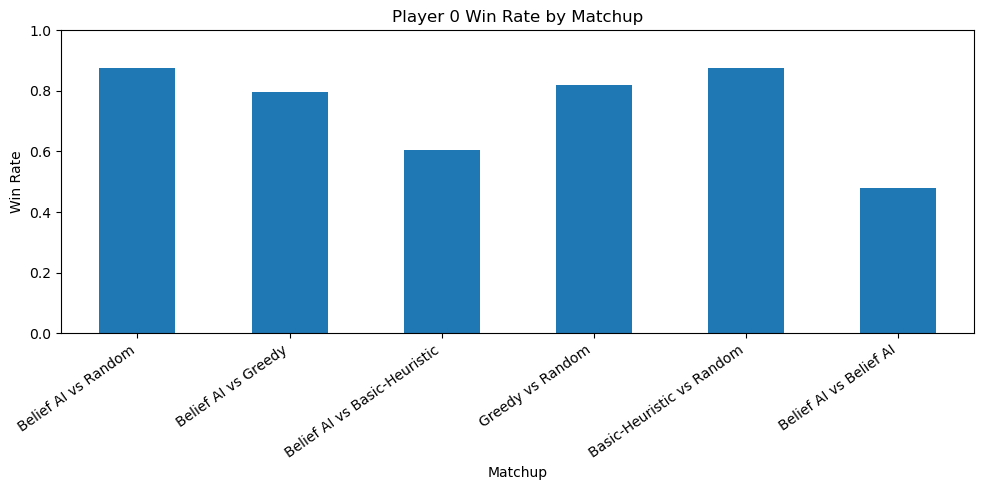

In [10]:
# Plot Player 0 win rates for each matchup.
ax = results_df["P0 Win Rate"].plot(kind="bar", figsize=(10, 5))
ax.set_title("Player 0 Win Rate by Matchup")
ax.set_ylabel("Win Rate")
ax.set_xlabel("Matchup")
ax.set_ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 12. Robustness Across Trump Suits

The next experiment checks whether the AI only performs well under one trump suit or whether the performance is stable across different suits.

This uses the matchup:

**Belief Heuristic AI vs Greedy Agent**


In [11]:
ai_vs_greedy_df = run_matchup_detailed(AI, GREEDY, n_games=1000, base_seed=2)

robustness_df = (
    ai_vs_greedy_df
    .groupby("trump_suit")
    .agg(
        Games=("game", "count"),
        AI_Win_Rate=("p0_win", "mean"),
        Avg_Score_Diff=("score_diff", "mean"),
        Std_Score_Diff=("score_diff", "std")
    )
    .sort_index()
)

robustness_df.round(3)


,Games,AI_Win_Rate,Avg_Score_Diff,Std_Score_Diff
trump_suit,,,,
Bastos,245,0.776,27.086,32.497
Copas,234,0.791,26.462,30.974
Espadas,259,0.795,27.544,31.532
Oros,262,0.828,28.588,29.956


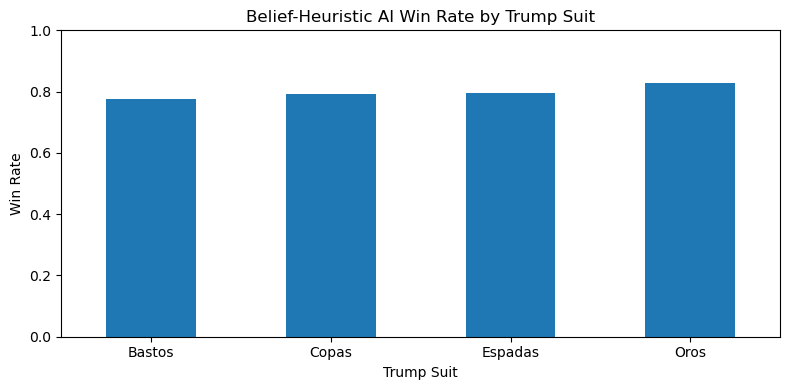

In [ ]:
ax = robustness_df["AI_Win_Rate"].plot(kind="bar", figsize=(8, 4))
ax.set_title("Belief Heuristic AI Win Rate by Trump Suit")
ax.set_ylabel("Win Rate")
ax.set_xlabel("Trump Suit")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 13. Results Analysis

The results show that the **Belief Heuristic AI performs strongly against the main baselines**.

### Main findings

- Against the random agent, the AI wins a large majority of games.
- Against the greedy agent, the AI still wins clearly, showing that it is better than simply grabbing points immediately.
- Against the basic heuristic agent, the AI has a smaller but still positive advantage.
- In AI vs AI games, the results are close to balanced, which suggests the game engine is not heavily biased toward Player 0 or Player 1.
- The trump-suit robustness table shows that the AI remains competitive across all four suits.

### Why the AI performs well

The AI does better because it does not only ask:

> "Which card gives me points right now?"

It also asks:

> "How likely is this card to be captured?"
>
> "Is this trick worth spending a trump card?"
>
> "Should I save my high cards for later?"
>
> "Can I win cheaply?"

This makes the agent more strategic than the random and greedy baselines.


## 14. Limitations

This AI is intentionally explainable and lightweight, but it has limitations.

1. **No deep search:**  
   The AI does not search many future turns.

2. **No Monte Carlo simulation:**  
   The AI does not sample possible future games. This was a design choice because this project uses the partially observable game approach instead.

3. **No learning:**  
   The AI does not improve through training.

4. **Simplified opponent model:**  
   The AI estimates hidden-card risk, but it does not learn a specific opponent's style.

5. **Two-player scope:**  
   The project focuses on two-player Brisca. A four-player team version would require partner modeling.

These limitations are acceptable for the project because the goal is to demonstrate adversarial reasoning under uncertainty with clear evaluation.


## 15. Optional Human or Tournament Testing

The assignment recommends testing against humans if possible. The following class can be used in a live notebook session to let a human choose cards manually.

This cell is not run automatically because it requires keyboard input.

We decided to focus on the data from the comparisons with other agents because with the agents we were able to get a larger sample size and perform more analysis on the performance of the belief state AI. So while the human vs AI experiment was implemented, no data was compiled.


In [13]:
class HumanAgent(Agent):
    name = "Human"

    def choose_card(self, obs: Dict[str, Any]) -> Card:
        hand = obs["hand"]

        print("\nYour hand:")
        for index, card in enumerate(hand):
            print(f"{index}: {card} | points={card.points()}")

        if obs["lead_card"] is not None:
            print("Lead card:", obs["lead_card"])

        print("Trump suit:", obs["trump_suit"])
        print("Current score:", obs["scores"])

        while True:
            try:
                choice = int(input("Choose card index: "))
                if 0 <= choice < len(hand):
                    return hand[choice]
            except ValueError:
                pass

            print("Invalid choice. Try again.")


# To play manually, remove the comment below:
# play_game(HumanAgent(), BeliefHeuristicAgent(), seed=123, verbose=True)


## 16. Conclusion

This project implemented Brisca as a partially observable adversarial game and evaluated several agents over many games.

The best agent was the **Belief Heuristic AI**, which uses card memory, trump awareness, and deterministic risk estimation. It performed better than random, greedy, and basic heuristic baselines in the repeated experiments.

The main conclusion is that even without Monte Carlo simulation or neural networks, a well-designed belief state heuristic can produce strong adversarial behavior in a hidden-information card game.


## References

[1] Naipes Heraclio Fournier, "How to play Brisca."  
https://www.nhfournier.es/en/como-jugar/brisca/

[2] Ludoteka, "Brisca - Game rules."  
https://www.ludoteka.com/clasika/brisca-en.html

[3] Solitaire Paradise, "Brisca."  
https://www.solitaireparadise.com/games_list/brisca.html
